In [19]:
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
class Pattern:
    def __init__(self, input, output):
        self.input = input
        self.output = output

In [21]:
class Data:
    def __init__(self, patterns):
        self.patterns = patterns

In [22]:
# تعریف Dropout
def apply_dropout(layer, dropout_rate):
    """
    Apply dropout to a layer.
    :param layer: The layer to apply dropout to.
    :param dropout_rate: The probability of dropping a neuron.
    :return: The layer with dropout applied.
    """
    if dropout_rate < 0 or dropout_rate >= 1:
        raise ValueError("Dropout rate must be in the range [0, 1).")
    mask = np.random.binomial(1, 1 - dropout_rate, size=layer.shape)
    return layer * mask / (1 - dropout_rate)  # Scale the output to maintain the expected value

In [23]:
class RBFNetwork:
    def __init__(self, no_of_input, no_of_hidden, no_of_output, data, learning_rate=0.0262, sigma_range=(0.1, 1.0), 
                 weight_range=(0, 1), bias_range=(0, 1), dropout_rate=0.5):
        """
        Initialize the RBF Network with customizable hyperparameters.

        :param no_of_input: Number of input features.
        :param no_of_hidden: Number of hidden neurons.
        :param no_of_output: Number of output neurons.
        :param data: Training data.
        :param learning_rate: Learning rate for gradient descent (default: 0.0262).
        :param sigma_range: Range for initial sigma values (default: (0.1, 1.0)).
        :param weight_range: Range for initial weights (default: (0, 1)).
        :param bias_range: Range for initial biases (default: (0, 1)).
        :param dropout_rate: Dropout rate for regularization (default: 0.5).
        """
        self.no_of_input = no_of_input
        self.no_of_hidden = no_of_hidden
        self.no_of_output = no_of_output
        self.data = data
        self.input = np.zeros(self.no_of_input)
        self.centroid = np.zeros((self.no_of_hidden, self.no_of_input))
        self.sigma = np.zeros(self.no_of_hidden)
        self.hidden_output = np.zeros(self.no_of_hidden)
        self.hidden_to_output_weight = np.zeros((self.no_of_hidden, self.no_of_output))
        self.output = np.zeros(self.no_of_output)
        self.output_bias = np.zeros(self.no_of_output)
        self.actual_target_values = []
        self.total = 0
        self.learningRate = learning_rate
        self.sigma_range = sigma_range
        self.weight_range = weight_range
        self.bias_range = bias_range
        self.dropout_rate = dropout_rate  # Dropout rate
        self.setup_center()
        self.setup_sigma_spread_radius()
        self.set_up_hidden_to_ouput_weight()
        self.set_up_output_bias()

    def setup_center(self):
        """Setup center using clustering ,for now just randomize between 0 and 1"""
        # print("Setup center")
        for i in range(self.no_of_hidden):
            self.centroid[i] = np.random.uniform(0, 1, self.no_of_input)

    def setup_sigma_spread_radius(self):
        for i in range(self.no_of_hidden):
            self.sigma[i] = np.random.uniform(0.1, 1.0)  # مقدار اولیه sigma بین 0.1 و 1.0

    def set_up_sigma_for_center(self, center):
        # print("Get sigma for center")
        p = self.no_of_hidden / 3
        sigma = 0
        distances = [0 for i in range(self.no_of_hidden)]
        for i in range(self.no_of_hidden):
            distances[i] = self.euclidean_distance(center, self.centroid[i])
            # print("Distance ", i, distances[i])
        sum = 0
        for i in range(int(p)):
            nearest = self.get_smallest_index(distances)
            distances[nearest] = float("inf")

            neighbour_centroid = self.centroid[nearest]
            for j in range(len(neighbour_centroid)):
                sum += (center[j] - neighbour_centroid[j]) ** 2

        sigma = sum / p
        sigma = math.sqrt(sigma)
        #return random.uniform(0, 1) * 6
        return sigma

    @staticmethod
    def euclidean_distance( x, y):
        return np.linalg.norm(x-y)

    @staticmethod
    def get_smallest_index( distances):
        min_index = 0
        for i in range(len(distances)):
            if (distances[min_index] > distances[i]):
                min_index = i
        return min_index

    def set_up_hidden_to_ouput_weight(self):
        print("Setup hidden to output weight")
        self.hidden_to_output_weight = np.random.uniform(0, 1, (self.no_of_hidden, self.no_of_output))

        print("Hiden to output weight ", self.hidden_to_output_weight)

    def set_up_output_bias(self):
        print("Setup output bias")
        self.output_bias = np.random.uniform(0, 1, self.no_of_output)

    # train n iteration
    def train(self, n):
        for i in range(n):
            error = self.pass_one_epoch()
            print("Iteration ", i, " Error ", error)

        return error

    # Train an epoch and return total MSE
    def pass_one_epoch(self):
        # print("Pass one epoch")
        all_error = 0
        all_index = []
        for i in range(len(self.data.patterns)):
            all_index.append(i)
        # print("All index ",all_index)

        for i in range(len(self.data.patterns)):
            random_index = (int)(random.uniform(0, 1) * len(all_index))
            # print("Random index ",random_index, " Len ", len(all_index))
            """Get a random pattern to train"""
            pattern = self.data.patterns[random_index]
            del all_index[random_index]

            input = pattern.input
            self.actual_target_values = pattern.output
            self.pass_input_to_network(input)

            error = self.get_error_for_pattern()
            all_error += error
            self.gradient_descent()

        all_error = all_error / (len(self.data.patterns))
        return all_error

    def pass_input_to_network(self, input):
        self.input = input
        self.pass_to_hidden_node()
        self.pass_to_output_node()

    def pass_to_hidden_node(self):
        # محاسبه خروجی لایه پنهان
        self.hidden_output = np.zeros(self.no_of_hidden)
        for i in range(len(self.hidden_output)):
            euclid_distance = self.euclidean_distance(self.input, self.centroid[i]) ** 2
            self.hidden_output[i] = math.exp(- (euclid_distance / (2 * self.sigma[i] * self.sigma[i])))

        # اعمال Dropout به لایه پنهان
        if self.dropout_rate > 0:
            self.hidden_output = apply_dropout(self.hidden_output, self.dropout_rate)

    def pass_to_output_node(self):
        # محاسبه خروجی لایه خروجی
        self.output = [0 for i in range(self.no_of_output)]
        for i in range(self.no_of_output):
            output_value = 0
            for j in range(self.no_of_hidden):
                self.output[i] += self.hidden_to_output_weight[j][i] * self.hidden_output[j]
            self.output[i] += self.output_bias[i]  # اضافه کردن بایاس به خروجی

        # اعمال Dropout به لایه خروجی (اختیاری)
        if self.dropout_rate > 0:
            self.output = apply_dropout(np.array(self.output), self.dropout_rate)

    # Compute error for the pattern
    def get_error_for_pattern(self):
        error = 0
        for i in range(len(self.output)):
            error += (self.actual_target_values[i] - self.output[i]) ** 2
        return error

    # Weight update by gradient descent algorithm
    def gradient_descent(self):
        # compute the error of output layer
        self.mean_error = 0
        self.error_of_output_layer = [0 for i in range(self.no_of_output)]
        for i in range(self.no_of_output):
            self.error_of_output_layer[i] = (float)(self.actual_target_values[i] - self.output[i])
            e = (float)(self.actual_target_values[i] - self.output[i]) ** 2 * 0.5
            self.mean_error += e

        # Adjust hidden to output weight
        for o in range(self.no_of_output):
            for h in range(self.no_of_hidden):
                delta_weight = self.learningRate * self.error_of_output_layer[o] * self.hidden_output[h]
                self.hidden_to_output_weight[h][o] += delta_weight

        # For bias
        for o in range(self.no_of_output):
            delta_bias = self.learningRate * self.error_of_output_layer[o]
            self.output_bias[o] += delta_bias

        # Adjust center , input to hidden weight
        for i in range(self.no_of_input):
            for j in range(self.no_of_hidden):
                summ = 0
                for p in range(self.no_of_output):
                    summ += self.hidden_to_output_weight[j][p] * (self.actual_target_values[p] - self.output[p])

                second_part = (float)((self.input[i] - self.centroid[j][i]) / math.pow(self.sigma[j], 2))
                delta_weight = (float)(self.learningRate * self.hidden_output[j] * second_part * summ)
                self.centroid[j][i] += delta_weight

        # Adjust sigma and spread radius
        for i in range(self.no_of_input):
            for j in range(self.no_of_hidden):
                summ = 0
                for p in range(self.no_of_output):
                    summ += self.hidden_to_output_weight[j][p] * (self.actual_target_values[p] - self.output[p])

                second_part = (float)(
                    (math.pow((self.input[i] - self.centroid[j][i]), 2)) / math.pow(self.sigma[j], 3));
                delta_weight = (float)(0.1 * self.learningRate * self.hidden_output[j] * second_part * summ);
                self.sigma[j] += delta_weight
        return self.mean_error

    def get_accuracy_for_training(self):
        # برای رگرسیون، دقت به معنای خطای میانگین مربعات است
        total_error = 0
        for i in range(len(self.data.patterns)):
            pattern = self.data.patterns[i]
            self.pass_input_to_network(pattern.input)
            n_output = self.output
            act_output = pattern.output
            error = self.get_error_for_pattern()
            total_error += error
        mse = total_error / len(self.data.patterns)
        return mse

    def get_fired_neuron(self, output):
        max = 0
        for i in range(len(output)):
            if (output[i] > output[max]):
                max = i
        return max

In [24]:
# تابع محاسبه Mean Absolute Error (MAE)
def calculate_mae(true_values, predicted_values):
    return np.mean(np.abs(true_values - predicted_values))

# تابع محاسبه Root Mean Squared Error (RMSE)
def calculate_rmse(true_values, predicted_values):
    return np.sqrt(np.mean((true_values - predicted_values) ** 2))

# تابع محاسبه R-squared (R²)
def calculate_r2(true_values, predicted_values):
    mean_true = np.mean(true_values)
    ss_total = np.sum((true_values - mean_true) ** 2)
    ss_residual = np.sum((true_values - predicted_values) ** 2)
    return 1 - (ss_residual / ss_total)

# تابع محاسبه Mean Absolute Percentage Error (MAPE)
def calculate_mape(true_values, predicted_values):
    return np.mean(np.abs((true_values - predicted_values) / true_values)) * 100

# تابع محاسبه Median Absolute Error (MedAE)
def calculate_medae(true_values, predicted_values):
    return np.median(np.abs(true_values - predicted_values))

# تابع محاسبه Mean Squared Logarithmic Error (MSLE)
def calculate_msle(true_values, predicted_values):
    return np.mean((np.log1p(true_values) - np.log1p(predicted_values)) ** 2)

# تابع محاسبه Huber Loss
def calculate_huber_loss(true_values, predicted_values, delta=1.0):
    error = np.abs(true_values - predicted_values)
    return np.where(error <= delta, 0.5 * error ** 2, delta * (error - 0.5 * delta))

# تابع محاسبه Mean Relative Error (MRE)
def calculate_mre(true_values, predicted_values):
    return np.mean(np.abs((true_values - predicted_values) / true_values))

In [25]:
data_test = pd.read_csv('testdata.csv', header=None)
data_train = pd.read_csv('finaldata.csv', header=None)

In [26]:
train_patterns = []
for index, row in data_train.iterrows():
    input_value = [row[0]]  # ورودی به صورت لیست
    output_value = [row[1]]  # خروجی به صورت لیست
    train_patterns.append(Pattern(input=input_value, output=output_value))

test_patterns = []
for index, row in data_test.iterrows():
    input_value = [row[0]]  # ورودی به صورت لیست
    output_value = [row[1]]  # خروجی به صورت لیست
    test_patterns.append(Pattern(input=input_value, output=output_value))

train_data = Data(train_patterns)
test_data = Data(test_patterns)

In [27]:
rbf_network = RBFNetwork(no_of_input=1, no_of_hidden=5, no_of_output=1, data=train_data)

Setup hidden to output weight
Hiden to output weight  [[0.60722749]
 [0.03962609]
 [0.19578902]
 [0.60272494]
 [0.51811794]]
Setup output bias


In [28]:
# آموزش شبکه
rbf_network.train(n=1000)

Iteration  0  Error  0.520661210741546
Iteration  1  Error  1.0270336546470769
Iteration  2  Error  0.15873215570638585
Iteration  3  Error  0.27332963439954505
Iteration  4  Error  0.1243922353207655
Iteration  5  Error  0.1836306054896567
Iteration  6  Error  0.23250113435310985
Iteration  7  Error  0.21419798560950806
Iteration  8  Error  0.15916547300221942
Iteration  9  Error  0.1366324152291943
Iteration  10  Error  0.17198862639488585
Iteration  11  Error  0.1644500082435804
Iteration  12  Error  0.14202022454980337
Iteration  13  Error  0.1132510946833537
Iteration  14  Error  0.14673688044095878
Iteration  15  Error  0.17088462492363232
Iteration  16  Error  0.1346541540424755
Iteration  17  Error  0.1309543499923528
Iteration  18  Error  0.17779519831028798
Iteration  19  Error  0.18578204512304047
Iteration  20  Error  0.17877420522841822
Iteration  21  Error  0.13248858203179412
Iteration  22  Error  0.14489500780709477
Iteration  23  Error  0.1960917394930392
Iteration  24

0.1303206039371213

In [29]:
# جمع‌آوری مقادیر واقعی و پیش‌بینی‌شده
true_values = []
predicted_values = []

for pattern in test_data.patterns:
    rbf_network.pass_input_to_network(pattern.input)
    true_values.append(pattern.output[0])  # مقدار واقعی
    predicted_values.append(rbf_network.output[0])  # مقدار پیش‌بینی‌شده

# تبدیل به آرایه NumPy برای محاسبات
true_values = np.array(true_values)
predicted_values = np.array(predicted_values)

In [30]:
# محاسبه معیارها
mae = calculate_mae(true_values, predicted_values)
rmse = calculate_rmse(true_values, predicted_values)
r2 = calculate_r2(true_values, predicted_values)
mape = calculate_mape(true_values, predicted_values)
medae = calculate_medae(true_values, predicted_values)
msle = calculate_msle(true_values, predicted_values)
huber_loss = np.mean(calculate_huber_loss(true_values, predicted_values))
mre = calculate_mre(true_values, predicted_values)

In [31]:
# چاپ نتایج
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
print(f"Median Absolute Error (MedAE): {medae}")
print(f"Mean Squared Logarithmic Error (MSLE): {msle}")
print(f"Huber Loss: {huber_loss}")
print(f"Mean Relative Error (MRE): {mre}")

Mean Absolute Error (MAE): 0.477082160309808
Root Mean Squared Error (RMSE): 0.5672291529582322
R-squared (R²): -1.2692345650971788
Mean Absolute Percentage Error (MAPE): 19039056618.074383%
Median Absolute Error (MedAE): 0.374005499602232
Mean Squared Logarithmic Error (MSLE): 0.5990835049196073
Huber Loss: 0.15912138163230735
Mean Relative Error (MRE): 190390566.18074384


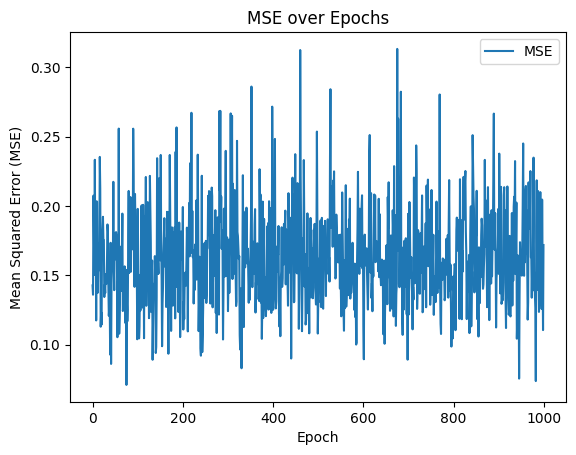

In [32]:
# لیست برای ذخیره مقادیر MSE در هر اپوک
mse_values = []

# تابع برای رسم نمودار
def plot_mse(mse_values):
    plt.plot(mse_values, label='MSE')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.title('MSE over Epochs')
    plt.legend()
    plt.show()

# آموزش شبکه و رسم نمودار در هر اپوک
for epoch in range(1000):
    error = rbf_network.pass_one_epoch()
    mse_values.append(error)

# نمایش نمودار نهایی
plot_mse(mse_values)

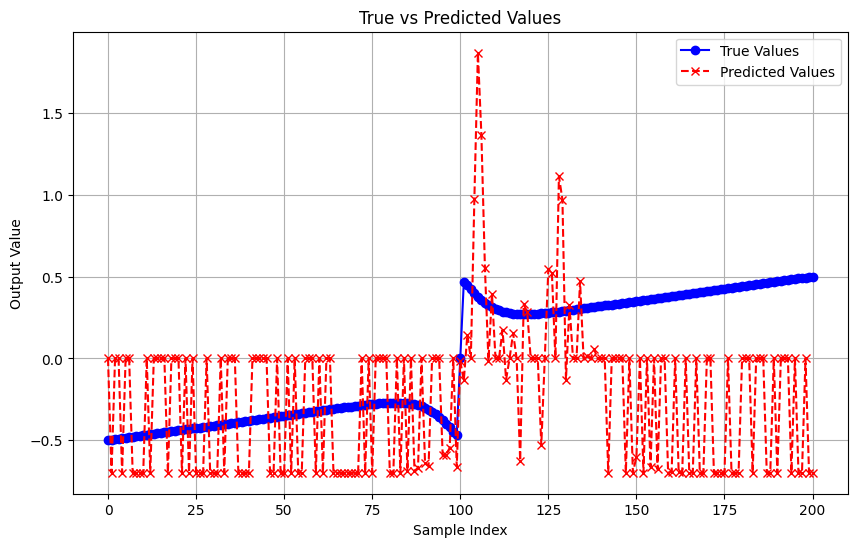

In [33]:
# رسم نمودار
plt.figure(figsize=(10, 6))
plt.plot(true_values, label='True Values', marker='o', linestyle='-', color='blue')
plt.plot(predicted_values, label='Predicted Values', marker='x', linestyle='--', color='red')
plt.xlabel('Sample Index')
plt.ylabel('Output Value')
plt.title('True vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
# تعریف لایه RNN ساده
class SimpleRNN:
    def __init__(self, input_size, hidden_size, output_size):
        """
        Initialize a simple RNN layer.
        :param input_size: Number of input features.
        :param hidden_size: Number of hidden units.
        :param output_size: Number of output units.
        """
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        # وزن‌ها و بایاس‌ها
        self.W_hh = np.random.randn(hidden_size, hidden_size) * 0.01  # وزن برای حالت پنهان
        self.W_xh = np.random.randn(input_size, hidden_size) * 0.01  # وزن برای ورودی
        self.W_hy = np.random.randn(hidden_size, output_size) * 0.01  # وزن برای خروجی
        self.b_h = np.zeros((1, hidden_size))  # بایاس برای حالت پنهان
        self.b_y = np.zeros((1, output_size))  # بایاس برای خروجی
        
        # حالت پنهان
        self.hidden_state = np.zeros((1, hidden_size))

    def forward(self, x):
        """
        Forward pass through the RNN.
        :param x: Input data.
        :return: Output of the RNN.
        """
        # به‌روزرسانی حالت پنهان
        self.hidden_state = np.tanh(np.dot(x, self.W_xh) + np.dot(self.hidden_state, self.W_hh) + self.b_h)
        
        # محاسبه خروجی
        output = np.dot(self.hidden_state, self.W_hy) + self.b_y
        return output

    def reset_hidden_state(self):
        """
        Reset the hidden state of the RNN.
        """
        self.hidden_state = np.zeros((1, self.hidden_size))


In [35]:
# RBF class with RNN recurrent layer
class RBFNetwork:
    def __init__(self, no_of_input, no_of_hidden, no_of_output, data, learning_rate=0.0262, sigma_range=(0.1, 1.0), 
                 weight_range=(0, 1), bias_range=(0, 1), dropout_rate=0.5):
        """
        Initialize the RBF Network with customizable hyperparameters.
        """
        self.no_of_input = no_of_input
        self.no_of_hidden = no_of_hidden
        self.no_of_output = no_of_output
        self.data = data
        self.input = np.zeros(self.no_of_input)
        self.centroid = np.zeros((self.no_of_hidden, self.no_of_input))
        self.sigma = np.zeros(self.no_of_hidden)
        self.hidden_output = np.zeros(self.no_of_hidden)
        self.hidden_to_output_weight = np.zeros((self.no_of_hidden, self.no_of_output))
        self.output = np.zeros(self.no_of_output)
        self.output_bias = np.zeros(self.no_of_output)
        self.actual_target_values = []
        self.total = 0
        self.learningRate = learning_rate
        self.sigma_range = sigma_range
        self.weight_range = weight_range
        self.bias_range = bias_range
        self.dropout_rate = dropout_rate  # Dropout rate
        
        # اضافه کردن لایه RNN
        self.rnn = SimpleRNN(input_size=no_of_output, hidden_size=10, output_size=no_of_output)
        
        self.setup_center()
        self.setup_sigma_spread_radius()
        self.set_up_hidden_to_ouput_weight()
        self.set_up_output_bias()

    def setup_center(self):
        """Setup center using clustering ,for now just randomize between 0 and 1"""
        # print("Setup center")
        for i in range(self.no_of_hidden):
            self.centroid[i] = np.random.uniform(0, 1, self.no_of_input)

    def setup_sigma_spread_radius(self):
        for i in range(self.no_of_hidden):
            self.sigma[i] = np.random.uniform(0.1, 1.0)  # مقدار اولیه sigma بین 0.1 و 1.0

    def set_up_sigma_for_center(self, center):
        # print("Get sigma for center")
        p = self.no_of_hidden / 3
        sigma = 0
        distances = [0 for i in range(self.no_of_hidden)]
        for i in range(self.no_of_hidden):
            distances[i] = self.euclidean_distance(center, self.centroid[i])
            # print("Distance ", i, distances[i])
        sum = 0
        for i in range(int(p)):
            nearest = self.get_smallest_index(distances)
            distances[nearest] = float("inf")

            neighbour_centroid = self.centroid[nearest]
            for j in range(len(neighbour_centroid)):
                sum += (center[j] - neighbour_centroid[j]) ** 2

        sigma = sum / p
        sigma = math.sqrt(sigma)
        #return random.uniform(0, 1) * 6
        return sigma

    @staticmethod
    def euclidean_distance( x, y):
        return np.linalg.norm(x-y)

    @staticmethod
    def get_smallest_index( distances):
        min_index = 0
        for i in range(len(distances)):
            if (distances[min_index] > distances[i]):
                min_index = i
        return min_index

    def set_up_hidden_to_ouput_weight(self):
        print("Setup hidden to output weight")
        self.hidden_to_output_weight = np.random.uniform(0, 1, (self.no_of_hidden, self.no_of_output))

        print("Hiden to output weight ", self.hidden_to_output_weight)

    def set_up_output_bias(self):
        print("Setup output bias")
        self.output_bias = np.random.uniform(0, 1, self.no_of_output)

    # train n iteration
    def train(self, n):
        for i in range(n):
            error = self.pass_one_epoch()
            print("Iteration ", i, " Error ", error)

        return error

    # Train an epoch and return total MSE
    def pass_one_epoch(self):
        # print("Pass one epoch")
        all_error = 0
        all_index = []
        for i in range(len(self.data.patterns)):
            all_index.append(i)
        # print("All index ",all_index)

        for i in range(len(self.data.patterns)):
            random_index = (int)(random.uniform(0, 1) * len(all_index))
            # print("Random index ",random_index, " Len ", len(all_index))
            """Get a random pattern to train"""
            pattern = self.data.patterns[random_index]
            del all_index[random_index]

            input = pattern.input
            self.actual_target_values = pattern.output
            self.pass_input_to_network(input)

            error = self.get_error_for_pattern()
            all_error += error
            self.gradient_descent()

        all_error = all_error / (len(self.data.patterns))
        return all_error

    def pass_input_to_network(self, input):
        self.input = input
        self.pass_to_hidden_node()
        self.pass_to_output_node()

    def pass_to_hidden_node(self):
        # محاسبه خروجی لایه پنهان
        self.hidden_output = np.zeros(self.no_of_hidden)
        for i in range(len(self.hidden_output)):
            euclid_distance = self.euclidean_distance(self.input, self.centroid[i]) ** 2
            self.hidden_output[i] = math.exp(- (euclid_distance / (2 * self.sigma[i] * self.sigma[i])))

        # اعمال Dropout به لایه پنهان
        if self.dropout_rate > 0:
            self.hidden_output = apply_dropout(self.hidden_output, self.dropout_rate)

    def pass_to_output_node(self):
        """
        Pass the hidden layer output to the output layer and then through the RNN.
        """
        # محاسبه خروجی لایه RBF
        self.output = [0 for i in range(self.no_of_output)]
        for i in range(self.no_of_output):
            output_value = 0
            for j in range(self.no_of_hidden):
                self.output[i] += self.hidden_to_output_weight[j][i] * self.hidden_output[j]
            self.output[i] += self.output_bias[i]  # اضافه کردن بایاس به خروجی
        
        # ارسال خروجی RBF به لایه RNN
        rnn_input = np.array(self.output).reshape(1, -1)  # تبدیل به شکل مناسب برای RNN
        self.output = self.rnn.forward(rnn_input).flatten()  # خروجی RNN
    # Compute error for the pattern
    def get_error_for_pattern(self):
        error = 0
        for i in range(len(self.output)):
            error += (self.actual_target_values[i] - self.output[i]) ** 2
        return error

    # Weight update by gradient descent algorithm
    def gradient_descent(self):
        # compute the error of output layer
        self.mean_error = 0
        self.error_of_output_layer = [0 for i in range(self.no_of_output)]
        for i in range(self.no_of_output):
            self.error_of_output_layer[i] = (float)(self.actual_target_values[i] - self.output[i])
            e = (float)(self.actual_target_values[i] - self.output[i]) ** 2 * 0.5
            self.mean_error += e

        # Adjust hidden to output weight
        for o in range(self.no_of_output):
            for h in range(self.no_of_hidden):
                delta_weight = self.learningRate * self.error_of_output_layer[o] * self.hidden_output[h]
                self.hidden_to_output_weight[h][o] += delta_weight

        # For bias
        for o in range(self.no_of_output):
            delta_bias = self.learningRate * self.error_of_output_layer[o]
            self.output_bias[o] += delta_bias

        # Adjust center , input to hidden weight
        for i in range(self.no_of_input):
            for j in range(self.no_of_hidden):
                summ = 0
                for p in range(self.no_of_output):
                    summ += self.hidden_to_output_weight[j][p] * (self.actual_target_values[p] - self.output[p])

                second_part = (float)((self.input[i] - self.centroid[j][i]) / math.pow(self.sigma[j], 2))
                delta_weight = (float)(self.learningRate * self.hidden_output[j] * second_part * summ)
                self.centroid[j][i] += delta_weight

        # Adjust sigma and spread radius
        for i in range(self.no_of_input):
            for j in range(self.no_of_hidden):
                summ = 0
                for p in range(self.no_of_output):
                    summ += self.hidden_to_output_weight[j][p] * (self.actual_target_values[p] - self.output[p])

                second_part = (float)(
                    (math.pow((self.input[i] - self.centroid[j][i]), 2)) / math.pow(self.sigma[j], 3));
                delta_weight = (float)(0.1 * self.learningRate * self.hidden_output[j] * second_part * summ);
                self.sigma[j] += delta_weight
        return self.mean_error

    def get_accuracy_for_training(self):
        # برای رگرسیون، دقت به معنای خطای میانگین مربعات است
        total_error = 0
        for i in range(len(self.data.patterns)):
            pattern = self.data.patterns[i]
            self.pass_input_to_network(pattern.input)
            n_output = self.output
            act_output = pattern.output
            error = self.get_error_for_pattern()
            total_error += error
        mse = total_error / len(self.data.patterns)
        return mse

    def get_fired_neuron(self, output):
        max = 0
        for i in range(len(output)):
            if (output[i] > output[max]):
                max = i
        return max

In [36]:
rbf_network = RBFNetwork(no_of_input=1, no_of_hidden=5, no_of_output=1, data=train_data)

Setup hidden to output weight
Hiden to output weight  [[0.50296272]
 [0.88517776]
 [0.15186196]
 [0.84191022]
 [0.253812  ]]
Setup output bias


In [37]:
# آموزش شبکه
rbf_network.train(n=1000)

Iteration  0  Error  0.1484965326505746
Iteration  1  Error  0.16880281218547566
Iteration  2  Error  0.1586622258807735
Iteration  3  Error  0.16378546610758962
Iteration  4  Error  0.15795232031862838
Iteration  5  Error  0.1648770537001177
Iteration  6  Error  0.14878130725827662
Iteration  7  Error  0.15445544245309767
Iteration  8  Error  0.16062648818186112
Iteration  9  Error  0.15308433296977364
Iteration  10  Error  0.16352380628171478
Iteration  11  Error  0.15024525456256785
Iteration  12  Error  0.17208026293149972
Iteration  13  Error  0.1605408348100824
Iteration  14  Error  0.14657283754553319
Iteration  15  Error  0.15058013131047743
Iteration  16  Error  0.15246528674417387
Iteration  17  Error  0.15621549992272732
Iteration  18  Error  0.16423204997696214
Iteration  19  Error  0.14792986679306544
Iteration  20  Error  0.15841637271290368
Iteration  21  Error  0.1626391557866893
Iteration  22  Error  0.16816830762929758
Iteration  23  Error  0.1598826054935606
Iteratio

0.1707178643002958

In [38]:
# جمع‌آوری مقادیر واقعی و پیش‌بینی‌شده
true_values = []
predicted_values = []

for pattern in test_data.patterns:
    rbf_network.pass_input_to_network(pattern.input)
    true_values.append(pattern.output[0])  # مقدار واقعی
    predicted_values.append(rbf_network.output[0])  # مقدار پیش‌بینی‌شده

# تبدیل به آرایه NumPy برای محاسبات
true_values = np.array(true_values)
predicted_values = np.array(predicted_values)

In [39]:
# محاسبه معیارها
mae = calculate_mae(true_values, predicted_values)
rmse = calculate_rmse(true_values, predicted_values)
r2 = calculate_r2(true_values, predicted_values)
mape = calculate_mape(true_values, predicted_values)
medae = calculate_medae(true_values, predicted_values)
msle = calculate_msle(true_values, predicted_values)
huber_loss = np.mean(calculate_huber_loss(true_values, predicted_values))
mre = calculate_mre(true_values, predicted_values)

In [44]:
# چاپ نتایج
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
print(f"Median Absolute Error (MedAE): {medae}")
print(f"Mean Squared Logarithmic Error (MSLE): {msle}")
print(f"Huber Loss: {huber_loss}")
print(f"Mean Relative Error (MRE): {mre}")

Mean Absolute Error (MAE): 0.36982330628529203
Root Mean Squared Error (RMSE): 0.3783403448493608
R-squared (R²): -0.009549490398335081
Mean Absolute Percentage Error (MAPE): 33044202664.093094%
Median Absolute Error (MedAE): 0.36850734018942194
Mean Squared Logarithmic Error (MSLE): 0.1723913046642998
Huber Loss: 0.07157070827036661
Mean Relative Error (MRE): 330442026.64093095


Epoch 0, MSE: 0.10883200955978324
Epoch 100, MSE: 0.005178287174583497
Epoch 200, MSE: 0.003470960418003627
Epoch 300, MSE: 0.0025780874506921344
Epoch 400, MSE: 0.0020623234004296786
Epoch 500, MSE: 0.0017533866977698911
Epoch 600, MSE: 0.0015589685869446517
Epoch 700, MSE: 0.0014296223277039677
Epoch 800, MSE: 0.0013388725242047606
Epoch 900, MSE: 0.0012722183627427632


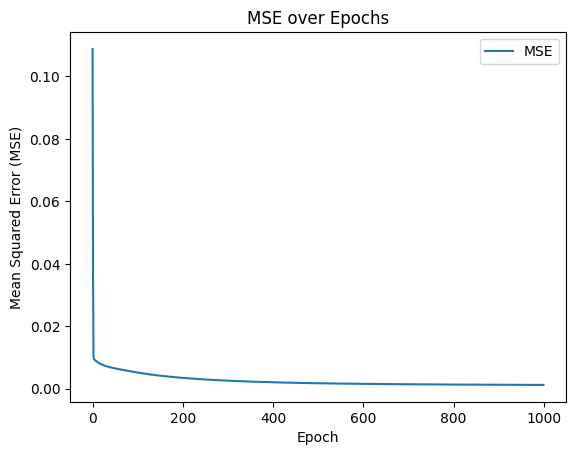

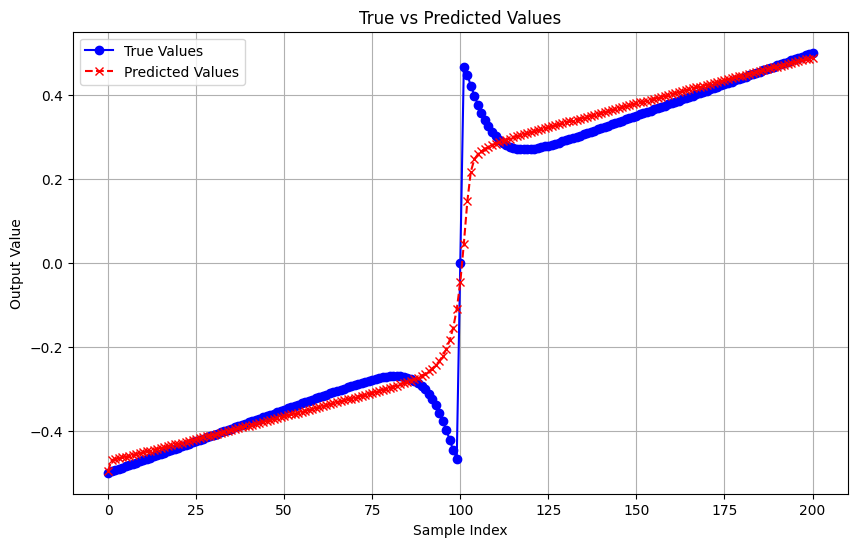

In [41]:
# train RNN model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random

# تعریف کلاس RNN
class SimpleRNN:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.0262):
        """
        Initialize a simple RNN.
        :param input_size: Number of input features.
        :param hidden_size: Number of hidden units.
        :param output_size: Number of output units.
        :param learning_rate: Learning rate for gradient descent.
        """
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        
        # وزن‌ها و بایاس‌ها
        self.W_xh = np.random.randn(input_size, hidden_size) * 0.01  # وزن برای ورودی به پنهان
        self.W_hh = np.random.randn(hidden_size, hidden_size) * 0.01  # وزن برای پنهان به پنهان
        self.W_hy = np.random.randn(hidden_size, output_size) * 0.01  # وزن برای پنهان به خروجی
        self.b_h = np.zeros((1, hidden_size))  # بایاس برای لایه پنهان
        self.b_y = np.zeros((1, output_size))  # بایاس برای لایه خروجی
        
        # حالت پنهان
        self.hidden_state = np.zeros((1, hidden_size))

    def forward(self, x):
        """
        Forward pass through the RNN.
        :param x: Input data (shape: [1, input_size]).
        :return: Output of the RNN.
        """
        # به‌روزرسانی حالت پنهان
        self.hidden_state = np.tanh(np.dot(x, self.W_xh) + np.dot(self.hidden_state, self.W_hh) + self.b_h)
        
        # محاسبه خروجی
        output = np.dot(self.hidden_state, self.W_hy) + self.b_y
        return output

    def backward(self, x, target):
        """
        Backward pass through the RNN (gradient descent).
        :param x: Input data (shape: [1, input_size]).
        :param target: Target output (shape: [1, output_size]).
        """
        # محاسبه خطا
        output = self.forward(x)
        error = output - target
        
        # گرادیان‌ها
        dW_hy = np.dot(self.hidden_state.T, error)
        db_y = error
        
        dh = np.dot(error, self.W_hy.T) * (1 - self.hidden_state ** 2)
        dW_xh = np.dot(x.T, dh)
        dW_hh = np.dot(self.hidden_state.T, dh)
        db_h = dh
        
        # به‌روزرسانی وزن‌ها و بایاس‌ها
        self.W_hy -= self.learning_rate * dW_hy
        self.b_y -= self.learning_rate * db_y
        self.W_xh -= self.learning_rate * dW_xh
        self.W_hh -= self.learning_rate * dW_hh
        self.b_h -= self.learning_rate * db_h

    def reset_hidden_state(self):
        """
        Reset the hidden state of the RNN.
        """
        self.hidden_state = np.zeros((1, self.hidden_size))

# کلاس‌های Pattern و Data بدون تغییر باقی می‌مانند.

class Pattern:
    def __init__(self, input, output):
        self.input = input
        self.output = output

class Data:
    def __init__(self, patterns):
        self.patterns = patterns

# آموزش مدل RNN
def train_rnn(rnn, data, epochs=1000):
    """
    Train the RNN model.
    :param rnn: The RNN model.
    :param data: Training data.
    :param epochs: Number of training epochs.
    """
    mse_values = []
    for epoch in range(epochs):
        total_error = 0
        for pattern in data.patterns:
            x = np.array(pattern.input).reshape(1, -1)  # ورودی
            y = np.array(pattern.output).reshape(1, -1)  # خروجی واقعی
            
            # پیش‌بینی و به‌روزرسانی وزن‌ها
            rnn.forward(x)
            rnn.backward(x, y)
            
            # محاسبه خطا
            error = np.mean((y - rnn.forward(x)) ** 2)
            total_error += error
        
        # محاسبه MSE برای این اپوک
        mse = total_error / len(data.patterns)
        mse_values.append(mse)
        
        # نمایش خطا هر ۱۰۰ اپوک
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, MSE: {mse}")
    
    # رسم نمودار خطا
    plt.plot(mse_values, label='MSE')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.title('MSE over Epochs')
    plt.legend()
    plt.show()

# تست مدل RNN
def test_rnn(rnn, data):
    """
    Test the RNN model.
    :param rnn: The RNN model.
    :param data: Test data.
    """
    true_values = []
    predicted_values = []
    
    for pattern in data.patterns:
        x = np.array(pattern.input).reshape(1, -1)  # ورودی
        y = np.array(pattern.output).reshape(1, -1)  # خروجی واقعی
        
        # پیش‌بینی
        y_pred = rnn.forward(x)
        
        true_values.append(y[0][0])
        predicted_values.append(y_pred[0][0])
    
    # رسم نمودار خروجی واقعی و پیش‌بینی‌شده
    plt.figure(figsize=(10, 6))
    plt.plot(true_values, label='True Values', marker='o', linestyle='-', color='blue')
    plt.plot(predicted_values, label='Predicted Values', marker='x', linestyle='--', color='red')
    plt.xlabel('Sample Index')
    plt.ylabel('Output Value')
    plt.title('True vs Predicted Values')
    plt.legend()
    plt.grid(True)
    plt.show()

# خواندن داده‌ها
data_test = pd.read_csv('testdata.csv', header=None)
data_train = pd.read_csv('finaldata.csv', header=None)

# آماده‌سازی داده‌های آموزش و تست
train_patterns = []
for index, row in data_train.iterrows():
    input_value = [row[0]]  # ورودی به صورت لیست
    output_value = [row[1]]  # خروجی به صورت لیست
    train_patterns.append(Pattern(input=input_value, output=output_value))

test_patterns = []
for index, row in data_test.iterrows():
    input_value = [row[0]]  # ورودی به صورت لیست
    output_value = [row[1]]  # خروجی به صورت لیست
    test_patterns.append(Pattern(input=input_value, output=output_value))

train_data = Data(train_patterns)
test_data = Data(test_patterns)

# ایجاد مدل RNN
rnn = SimpleRNN(input_size=1, hidden_size=5, output_size=1, learning_rate=0.0262)

# آموزش مدل RNN
train_rnn(rnn, train_data, epochs=1000)

# تست مدل RNN
test_rnn(rnn, test_data)

In [68]:
# better performance
class RBFNetwork:
    def __init__(self, no_of_input, no_of_hidden, no_of_output, data, learning_rate=0.01, sigma_range=(0.1, 1.0), 
                 weight_range=(-0.1, 0.1), bias_range=(-0.1, 0.1), dropout_rate=0.2):
        """
        Initialize the RBF Network with customizable hyperparameters.
        """
        self.no_of_input = no_of_input
        self.no_of_hidden = no_of_hidden
        self.no_of_output = no_of_output
        self.data = data
        self.input = np.zeros(self.no_of_input)
        self.centroid = np.zeros((self.no_of_hidden, self.no_of_input))
        self.sigma = np.zeros(self.no_of_hidden)
        self.hidden_output = np.zeros(self.no_of_hidden)
        self.hidden_to_output_weight = np.zeros((self.no_of_hidden, self.no_of_output))
        self.output = np.zeros(self.no_of_output)
        self.output_bias = np.zeros(self.no_of_output)
        self.actual_target_values = []
        self.total = 0
        self.learningRate = learning_rate
        self.sigma_range = sigma_range
        self.weight_range = weight_range
        self.bias_range = bias_range
        self.dropout_rate = dropout_rate  # Dropout rate
        self.setup_center()
        self.setup_sigma_spread_radius()
        self.set_up_hidden_to_ouput_weight()
        self.set_up_output_bias()

    def setup_center(self):
        """Setup center using clustering ,for now just randomize between 0 and 1"""
        for i in range(self.no_of_hidden):
            self.centroid[i] = np.random.uniform(0, 1, self.no_of_input)

    def setup_sigma_spread_radius(self):
        for i in range(self.no_of_hidden):
            self.sigma[i] = np.random.uniform(0.1, 1.0)  # مقدار اولیه sigma بین 0.1 و 1.0


    def set_up_sigma_for_center(self, center):
        # print("Get sigma for center")
        p = self.no_of_hidden / 3
        sigma = 0
        distances = [0 for i in range(self.no_of_hidden)]
        for i in range(self.no_of_hidden):
            distances[i] = self.euclidean_distance(center, self.centroid[i])
            # print("Distance ", i, distances[i])
        sum = 0
        for i in range(int(p)):
            nearest = self.get_smallest_index(distances)
            distances[nearest] = float("inf")

            neighbour_centroid = self.centroid[nearest]
            for j in range(len(neighbour_centroid)):
                sum += (center[j] - neighbour_centroid[j]) ** 2

        sigma = sum / p
        sigma = math.sqrt(sigma)
        #return random.uniform(0, 1) * 6
        return sigma

    @staticmethod
    def euclidean_distance( x, y):
        return np.linalg.norm(x-y)

    @staticmethod
    def get_smallest_index( distances):
        min_index = 0
        for i in range(len(distances)):
            if (distances[min_index] > distances[i]):
                min_index = i
        return min_index

    def set_up_hidden_to_ouput_weight(self):
        print("Setup hidden to output weight")
        self.hidden_to_output_weight = np.random.uniform(self.weight_range[0], self.weight_range[1], 
                                                         (self.no_of_hidden, self.no_of_output))

    def set_up_output_bias(self):
        print("Setup output bias")
        self.output_bias = np.random.uniform(self.bias_range[0], self.bias_range[1], self.no_of_output)

    def train(self, n, batch_size=10):
        for i in range(n):
            error = self.pass_one_epoch(batch_size)
            print("Iteration ", i, " Error ", error)

    # Train an epoch and return total MSE
    def pass_one_epoch(self, batch_size):
        all_error = 0
        indices = np.arange(len(self.data.patterns))
        np.random.shuffle(indices)  # Shuffle data

        for i in range(0, len(self.data.patterns), batch_size):
            batch_indices = indices[i:i + batch_size]
            batch_error = 0

            for idx in batch_indices:
                pattern = self.data.patterns[idx]
                input = pattern.input
                self.actual_target_values = pattern.output
                self.pass_input_to_network(input)

                error = self.get_error_for_pattern()
                batch_error += error
                self.gradient_descent()

            all_error += batch_error / batch_size

        return all_error / (len(self.data.patterns) // batch_size)

    def pass_input_to_network(self, input):
        self.input = input
        self.pass_to_hidden_node()
        self.pass_to_output_node()

    def pass_to_hidden_node(self):
        # محاسبه خروجی لایه پنهان
        self.hidden_output = np.zeros(self.no_of_hidden)
        for i in range(len(self.hidden_output)):
            euclid_distance = self.euclidean_distance(self.input, self.centroid[i]) ** 2
            self.hidden_output[i] = math.exp(- (euclid_distance / (2 * self.sigma[i] * self.sigma[i])))

        # اعمال Dropout به لایه پنهان
        if self.dropout_rate > 0:
            self.hidden_output = apply_dropout(self.hidden_output, self.dropout_rate)

    def pass_to_output_node(self):
        # محاسبه خروجی لایه خروجی
        self.output = [0 for i in range(self.no_of_output)]
        for i in range(self.no_of_output):
            output_value = 0
            for j in range(self.no_of_hidden):
                self.output[i] += self.hidden_to_output_weight[j][i] * self.hidden_output[j]
            self.output[i] += self.output_bias[i]  # اضافه کردن بایاس به خروجی

        # اعمال Dropout به لایه خروجی (اختیاری)
        if self.dropout_rate > 0:
            self.output = apply_dropout(np.array(self.output), self.dropout_rate)

    # Compute error for the pattern
    def get_error_for_pattern(self):
        error = 0
        for i in range(len(self.output)):
            error += (self.actual_target_values[i] - self.output[i]) ** 2
        return error

    # Weight update by gradient descent algorithm
    def gradient_descent(self):
        # compute the error of output layer
        self.mean_error = 0
        self.error_of_output_layer = [0 for i in range(self.no_of_output)]
        for i in range(self.no_of_output):
            self.error_of_output_layer[i] = (float)(self.actual_target_values[i] - self.output[i])
            e = (float)(self.actual_target_values[i] - self.output[i]) ** 2 * 0.5
            self.mean_error += e

        # Adjust hidden to output weight
        for o in range(self.no_of_output):
            for h in range(self.no_of_hidden):
                delta_weight = self.learningRate * self.error_of_output_layer[o] * self.hidden_output[h]
                self.hidden_to_output_weight[h][o] += delta_weight

        # For bias
        for o in range(self.no_of_output):
            delta_bias = self.learningRate * self.error_of_output_layer[o]
            self.output_bias[o] += delta_bias

        # Adjust center , input to hidden weight
        for i in range(self.no_of_input):
            for j in range(self.no_of_hidden):
                summ = 0
                for p in range(self.no_of_output):
                    summ += self.hidden_to_output_weight[j][p] * (self.actual_target_values[p] - self.output[p])

                second_part = (float)((self.input[i] - self.centroid[j][i]) / math.pow(self.sigma[j], 2))
                delta_weight = (float)(self.learningRate * self.hidden_output[j] * second_part * summ)
                self.centroid[j][i] += delta_weight

        # Adjust sigma and spread radius
        for i in range(self.no_of_input):
            for j in range(self.no_of_hidden):
                summ = 0
                for p in range(self.no_of_output):
                    summ += self.hidden_to_output_weight[j][p] * (self.actual_target_values[p] - self.output[p])

                second_part = (float)(
                    (math.pow((self.input[i] - self.centroid[j][i]), 2)) / math.pow(self.sigma[j], 3));
                delta_weight = (float)(0.1 * self.learningRate * self.hidden_output[j] * second_part * summ);
                self.sigma[j] += delta_weight
        return self.mean_error

    def get_accuracy_for_training(self):
        # برای رگرسیون، دقت به معنای خطای میانگین مربعات است
        total_error = 0
        for i in range(len(self.data.patterns)):
            pattern = self.data.patterns[i]
            self.pass_input_to_network(pattern.input)
            n_output = self.output
            act_output = pattern.output
            error = self.get_error_for_pattern()
            total_error += error
        mse = total_error / len(self.data.patterns)
        return mse

    def get_fired_neuron(self, output):
        max = 0
        for i in range(len(output)):
            if (output[i] > output[max]):
                max = i
        return max

In [69]:
rbf_network = RBFNetwork(no_of_input=1, no_of_hidden=5, no_of_output=1, data=train_data)

Setup hidden to output weight
Setup output bias


In [70]:
# آموزش شبکه
rbf_network.train(n=1000)

Iteration  0  Error  0.14900140837320947
Iteration  1  Error  0.14956873513117888
Iteration  2  Error  0.1452854802894596
Iteration  3  Error  0.1431932239523491
Iteration  4  Error  0.14564826163525532
Iteration  5  Error  0.14176913832910976
Iteration  6  Error  0.14319677022270924
Iteration  7  Error  0.1414385298803658
Iteration  8  Error  0.1397193407819837
Iteration  9  Error  0.1412231566192105
Iteration  10  Error  0.1387094428099744
Iteration  11  Error  0.13956568320695004
Iteration  12  Error  0.1397603927637354
Iteration  13  Error  0.14269366651527024
Iteration  14  Error  0.14159644169545296
Iteration  15  Error  0.1425525520775149
Iteration  16  Error  0.14281886231394675
Iteration  17  Error  0.14003035854749196
Iteration  18  Error  0.14109784938991615
Iteration  19  Error  0.1431686328014432
Iteration  20  Error  0.14072768245565162
Iteration  21  Error  0.14144492724560145
Iteration  22  Error  0.13869955507487117
Iteration  23  Error  0.14386307759519704
Iteration  

In [71]:
# جمع‌آوری مقادیر واقعی و پیش‌بینی‌شده
true_values = []
predicted_values = []

for pattern in test_data.patterns:
    rbf_network.pass_input_to_network(pattern.input)
    true_values.append(pattern.output[0])  # مقدار واقعی
    predicted_values.append(rbf_network.output[0])  # مقدار پیش‌بینی‌شده

# تبدیل به آرایه NumPy برای محاسبات
true_values = np.array(true_values)
predicted_values = np.array(predicted_values)

In [72]:
# محاسبه معیارها
mae = calculate_mae(true_values, predicted_values)
rmse = calculate_rmse(true_values, predicted_values)
r2 = calculate_r2(true_values, predicted_values)
mape = calculate_mape(true_values, predicted_values)
medae = calculate_medae(true_values, predicted_values)
msle = calculate_msle(true_values, predicted_values)
huber_loss = np.mean(calculate_huber_loss(true_values, predicted_values))
mre = calculate_mre(true_values, predicted_values)

In [73]:
# چاپ نتایج
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
print(f"Median Absolute Error (MedAE): {medae}")
print(f"Mean Squared Logarithmic Error (MSLE): {msle}")
print(f"Huber Loss: {huber_loss}")
print(f"Mean Relative Error (MRE): {mre}")

Mean Absolute Error (MAE): 0.33084402903708804
Root Mean Squared Error (RMSE): 0.3551371737050623
R-squared (R²): 0.11048234684193292
Mean Absolute Percentage Error (MAPE): 65008614153.35418%
Median Absolute Error (MedAE): 0.3577735295601904
Mean Squared Logarithmic Error (MSLE): 0.14636741204126882
Huber Loss: 0.06306120607360981
Mean Relative Error (MRE): 650086141.5335418


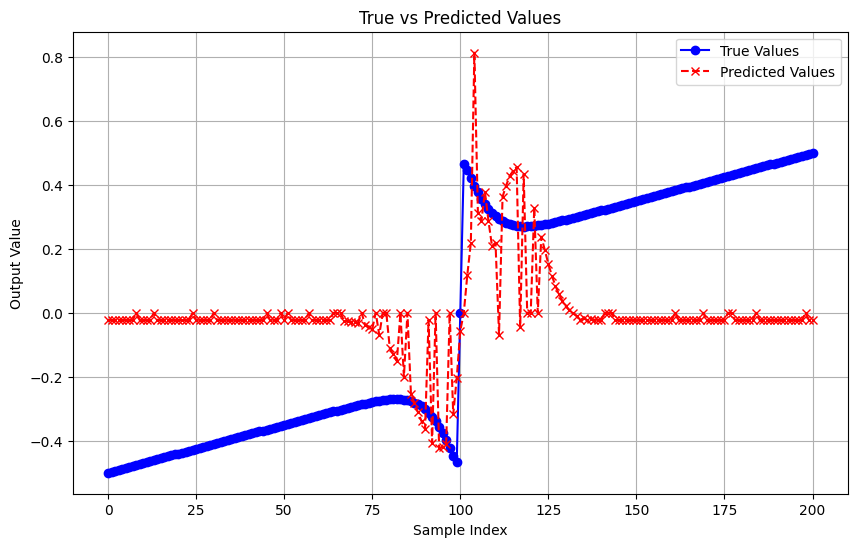

In [74]:
# رسم نمودار
plt.figure(figsize=(10, 6))
plt.plot(true_values, label='True Values', marker='o', linestyle='-', color='blue')
plt.plot(predicted_values, label='Predicted Values', marker='x', linestyle='--', color='red')
plt.xlabel('Sample Index')
plt.ylabel('Output Value')
plt.title('True vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

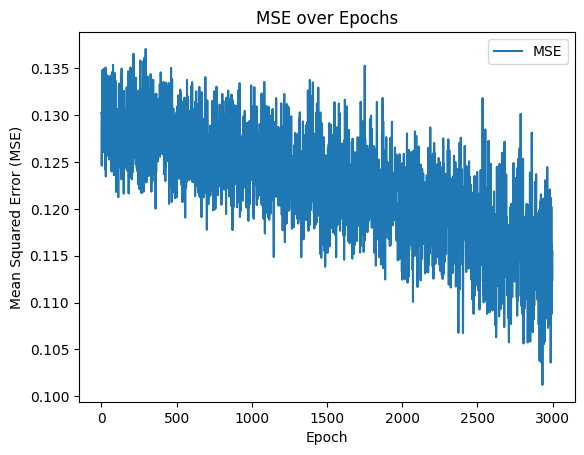

In [75]:
# لیست برای ذخیره مقادیر MSE در هر اپوک
mse_values = []

# تابع برای رسم نمودار
def plot_mse(mse_values):
    plt.plot(mse_values, label='MSE')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.title('MSE over Epochs')
    plt.legend()
    plt.show()

# آموزش شبکه و رسم نمودار در هر اپوک
for epoch in range(3000):
    error = rbf_network.pass_one_epoch(1)
    mse_values.append(error)

# نمایش نمودار نهایی
plot_mse(mse_values)